# Mulberry Leaf Defect Detection - Optimized Pipeline
This notebook downloads the dataset, applies data augmentation, trains a MobileNetV2 model with EarlyStopping and Checkpoints, evaluates the results (Confusion Matrix & Classification Report), and saves the model to `.h5`, `.keras`, and `.tflite`.

In [1]:
!pip install -q gdown scikit-learn seaborn matplotlib opencv-python
import os
import gdown
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 1. Download and Prepare Dataset

In [3]:
# folder_id = "10OmBK7HqUxqMNALnBBZg1uHkD06NGDIY"
output_dir = "Mulberry dataset"

# Downloading dataset from Google Drive 
# if not os.path.exists(output_dir):
#     gdown.download_folder(id=folder_id, output=output_dir, quiet=False, use_cookies=False)

train_dir = None
val_dir = None
test_dir = None

for root, dirs, files in os.walk(output_dir):
    if 'train' in dirs and 'val' in dirs and 'test' in dirs:
        train_dir = os.path.join(root, 'train')
        val_dir = os.path.join(root, 'val')
        test_dir = os.path.join(root, 'test')
        break

if train_dir is None:
    base_dir = "Mulberry dataset"
    if os.path.exists(base_dir):
        train_dir = f"{base_dir}/train"
        val_dir = f"{base_dir}/val"
        test_dir = f"{base_dir}/test"
    else:
        raise Exception("Dataset directories not found!")

print(f"Train: {train_dir}\nVal: {val_dir}\nTest: {test_dir}")

Train: Mulberry dataset\train
Val: Mulberry dataset\val
Test: Mulberry dataset\test


## 2. Data Augmentation and Generators

In [12]:
print("Setting up Data Generators...")
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

datagen_val_test = ImageDataGenerator(rescale=1./255)

train_generator = datagen_train.flow_from_directory(
    directory=train_dir,
    # keep_aspect_ratio=True,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

val_generator = datagen_val_test.flow_from_directory(
    directory=val_dir,
    # keep_aspect_ratio=True,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'
)

test_generator = datagen_val_test.flow_from_directory(
    directory=test_dir,
    # keep_aspect_ratio=True,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Setting up Data Generators...
Found 1357 images belonging to 3 classes.
Found 192 images belonging to 3 classes.
Found 392 images belonging to 3 classes.


## 3. Build Model (MobileNetV2)

In [13]:
print("Building MobileNetV2 Model...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='max'
)
base_model.trainable = False  # Freeze base model

inputs = base_model.input
outputs = tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')(base_model.output)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Building MobileNetV2 Model...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Training with Callbacks

In [14]:
callbacks = [
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Starting Training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

Starting Training...
Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - accuracy: 0.2743 - loss: 3.6821
Epoch 1: val_accuracy improved from None to 0.55729, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3987 - loss: 2.5978 - val_accuracy: 0.5573 - val_loss: 1.5439 - learning_rate: 1.0000e-04
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5723 - loss: 1.5899
Epoch 2: val_accuracy improved from 0.55729 to 0.61458, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5652 - loss: 1.4889 - val_accuracy: 0.6146 - val_loss: 1.1264 - learning_rate: 1.0000e-04
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accuracy: 0.5659 - loss: 1.3164
Epoch 3: val_accuracy improved from 0.61458 to 0.69792, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
43/43 ━━━━━━━━━━━━

## 5. Evaluation and Metrics

Evaluating on Test Set...
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 652ms/step - accuracy: 0.9056 - loss: 0.2614
Test Loss: 0.26141
Test Accuracy: 90.56%
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 653ms/step

Classification Report:
               precision    recall  f1-score   support

     Healthy     0.9498    0.9419    0.9458       241
        Rust     0.8571    0.8947    0.8755       114
        Spot     0.7647    0.7027    0.7324        37

    accuracy                         0.9056       392
   macro avg     0.8572    0.8464    0.8513       392
weighted avg     0.9054    0.9056    0.9052       392



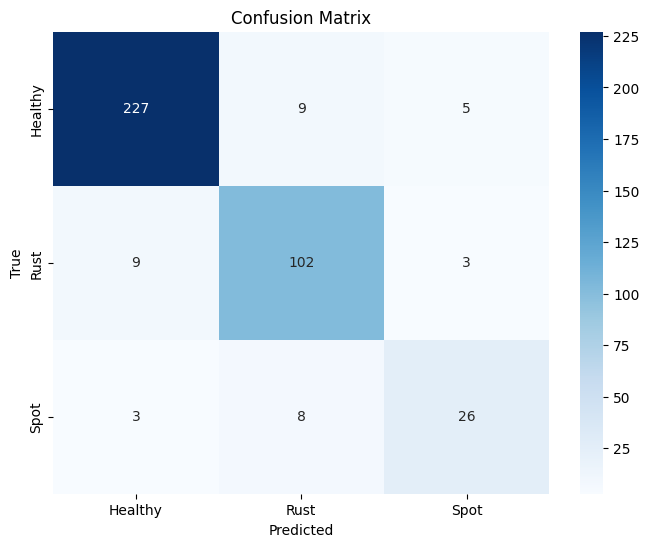

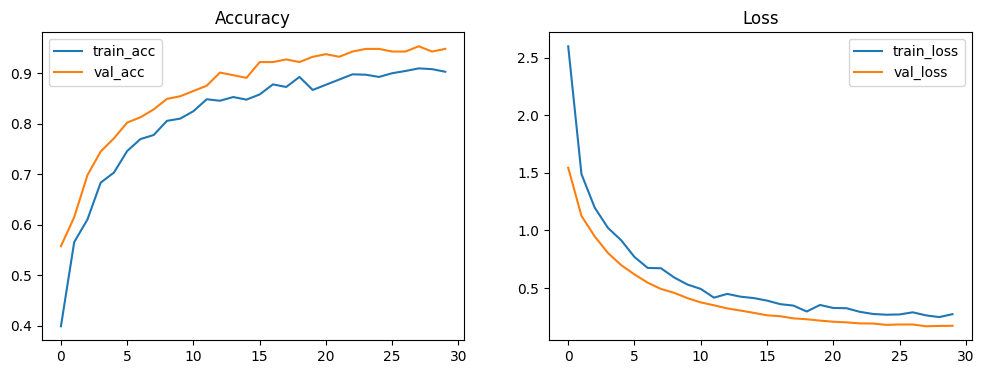

In [15]:
print("Evaluating on Test Set...")
results = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {results[0]:.5f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

pred = model.predict(test_generator)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_generator.classes

labels_dict = train_generator.class_indices
class_names = [k for k, v in sorted(labels_dict.items(), key=lambda item: item[1])]

report = classification_report(true_classes, pred_classes, target_names=class_names, digits=4)
print("\nClassification Report:\n", report)

cf_matrix = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()

## 6. Save Models (.h5 and .tflite)

In [16]:
model.save("mulberry_leaf_classification.h5")
print("Model saved as mulberry_leaf_classification.h5")

print("Converting to TFLite format...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('mulberry_leaf_classification.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model successfully converted and saved as mulberry_leaf_classification.tflite")

Model saved as mulberry_leaf_classification.h5
Converting to TFLite format...
INFO:tensorflow:Assets written to: C:\Users\Andre\AppData\Local\Temp\tmpftys6681\assets


INFO:tensorflow:Assets written to: C:\Users\Andre\AppData\Local\Temp\tmpftys6681\assets


Saved artifact at 'C:\Users\Andre\AppData\Local\Temp\tmpftys6681'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_362')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1339278529680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339278537744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339278530256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339238974480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1338460378256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339544568272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339544572880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339544571152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339544569424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1339544573840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

c:\1.MyProject\Mullberry leaf\myenv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


กำลังเริ่มประเมินผล TFLite Model... อาจใช้เวลาสักครู่
ประเมินผลเสร็จสิ้น!

TFLite Model Accuracy: 93.75%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.98      0.97       119
        Rust       0.92      0.88      0.90        56
        Spot       0.82      0.82      0.82        17

    accuracy                           0.94       192
   macro avg       0.90      0.89      0.90       192
weighted avg       0.94      0.94      0.94       192



c:\1.MyProject\Mullberry leaf\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\1.MyProject\Mullberry leaf\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\1.MyProject\Mullberry leaf\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\1.MyProject\Mullberry leaf\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\1.MyProject\Mullberry leaf\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}

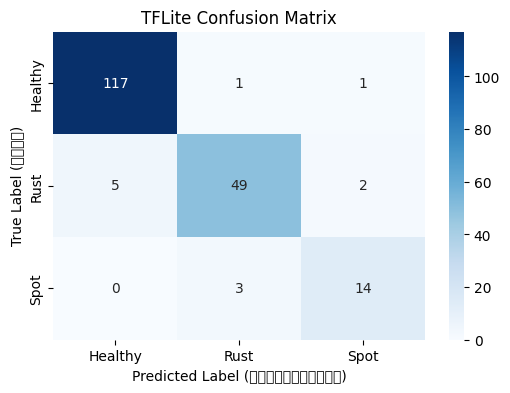

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. โหลดโมเดล TFLite ขึ้นมาเตรียมพร้อม
tflite_model_path = "mulberry_leaf_classification.tflite" 
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

# ดึงข้อมูลช่องทางเข้า (Input) และช่องทางออก (Output) ของโมเดล
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. เตรียมตัวแปรเก็บผลลัพธ์
y_true = [] 
y_pred = [] 

# *** สำคัญมาก: ตอนโหลด val_generator ควรตั้งค่า shuffle=False ด้วยนะครับ เพื่อให้เฉลยตรงกับลำดับรูป ***

print("กำลังเริ่มประเมินผล TFLite Model..")

# 3. วนลูปป้อนรูปภาพเข้า TFLite ทีละรูป
for i in range(len(val_generator)):
    images, labels = val_generator[i] 
    
    for j in range(len(images)):
        # ดึงรูปมา 1 รูป และขยายมิติให้กลายเป็น (1, 224, 224, 3) ตามที่ TFLite ต้องการ
        input_data = np.expand_dims(images[j], axis=0).astype(np.float32)
        
        # ส่งรูปเข้าไปใน TFLite
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke() # สั่งประมวลผล
        
        # ดึงผลลัพธ์ออกมา
        output_data = interpreter.get_tensor(output_details[0]['index'])
        predicted_class = np.argmax(output_data[0]) # หาคลาสที่ได้คะแนนสูงสุด
        y_pred.append(predicted_class)
        
        if val_generator.class_mode == 'sparse':
            true_class = int(labels[j])
        else:
            true_class = np.argmax(labels[j])
        y_true.append(true_class)

print("ประเมินผลเสร็จ\n")

# แสดงผลลัพธ์ Metrics
class_names = list(val_generator.class_indices.keys())

# ความแม่นยำรวม (Accuracy)
acc = accuracy_score(y_true, y_pred)
print(f"TFLite Model Accuracy: {acc * 100:.2f}%")

# Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# วาด Confusion Matrix 
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('TFLite Confusion Matrix')
plt.ylabel('True Label (เฉลย)')
plt.xlabel('Predicted Label (ที่โมเดลทาย)')
plt.show()